IMPORTAR LIBRERÍAS

In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

CARGAR DATASET

In [41]:
df = pd.read_csv("../data/processed/datos_tratados.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_Binary
0,0002-ORFBO,No,Female,No,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667,0.0
1,0003-MKNFE,No,Male,No,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667,0.0
2,0004-TLHLJ,Yes,Male,No,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333,1.0
3,0011-IGKFF,Yes,Male,Yes,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,1.0
4,0013-EXCHZ,Yes,Female,Yes,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667,1.0


REVISAR ESTRUCTURA DEL DATASET

In [42]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7043 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   str    
 4   customer.Partner           7267 non-null   int64  
 5   customer.Dependents        7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   int64  
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_Binary
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000,7043.000000
mean,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157337,0.265370
std,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004319,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333,0.000000
25%,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180833,0.000000
50%,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333,0.000000
75%,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995833,1.000000
max,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333,1.000000


ELIMINAR COLUMNAS IRRELEVANTES

In [43]:
df = df.drop(columns=["customerID"], errors="ignore")

df.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_Binary
0,No,Female,No,1,1,9,1,No,DSL,No,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667,0.0
1,No,Male,No,0,0,9,1,Yes,DSL,No,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667,0.0
2,Yes,Male,No,0,0,4,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333,1.0
3,Yes,Male,Yes,1,0,13,1,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,1.0
4,Yes,Female,Yes,1,0,3,1,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667,1.0


ENCODING DE VARIABLES CATEGÓRICAS

In [44]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_Binary,Churn_Yes,...,internet.TechSupport_Yes,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,1,1,9,1,1,65.6,593.30,2.186667,0.0,False,...,True,False,True,False,False,True,False,False,False,True
1,0,0,9,1,0,59.9,542.40,1.996667,0.0,False,...,False,False,False,False,True,False,False,False,False,True
2,0,0,4,1,1,73.9,280.85,2.463333,1.0,True,...,False,False,False,False,False,False,False,False,True,False
3,1,0,13,1,1,98.0,1237.85,3.266667,1.0,True,...,False,False,True,False,True,False,False,False,True,False
4,1,0,3,1,1,83.9,267.40,2.796667,1.0,True,...,True,False,True,False,False,False,False,False,False,True


SEPARAR VARIABLES PREDICTORAS Y VARIABLE OBJETIVO

In [45]:
df_encoded.columns

Index(['customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'account.PaperlessBilling',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias',
       'Churn_Binary', 'Churn_Yes', 'customer.gender_Male',
       'customer.SeniorCitizen_Yes', 'phone.MultipleLines_No phone service',
       'phone.MultipleLines_Yes', 'internet.InternetService_Fiber optic',
       'internet.InternetService_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes',
       'internet.TechSupport_No internet service', 'internet.TechSupport_Yes',
       'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes',
       'internet.StreamingMovies_No internet service',
       'internet.StreamingMovies_Yes', 'account.Contract_O

In [46]:
X = df_encoded.drop(["Churn_Binary", "Churn_Yes"], axis=1)

y = df_encoded["Churn_Binary"]

print(X.shape)
print(y.shape)

y.value_counts()

(7267, 31)
(7267,)


Churn_Binary
0.0    5174
1.0    1869
Name: count, dtype: int64

VERIFICAR PROPORCIÓN DE CANCELACIÓN

Distribución de Churn:
Churn_Binary
0.0    5174
1.0    1869
Name: count, dtype: int64
Distribución de Churn:
Churn_Binary
0.0    5174
1.0    1869
Name: count, dtype: int64


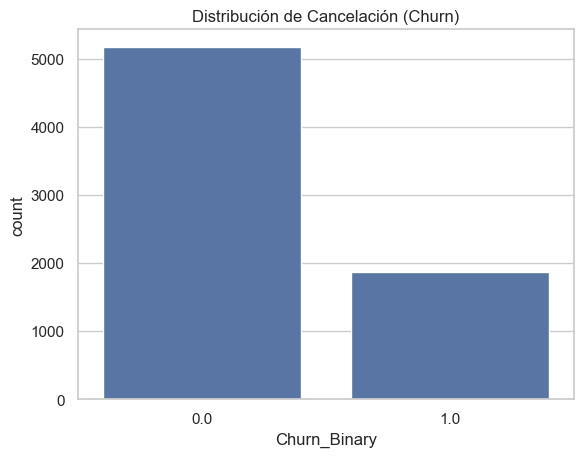

In [47]:
print("Distribución de Churn:")
print(y.value_counts())

print("Distribución de Churn:")
print(y.value_counts())

sns.countplot(x=y)

plt.title("Distribución de Cancelación (Churn)")

plt.show()

In [50]:
X.isna().sum().sort_values(ascending=False)
X.isna().sum().sum()

np.int64(11)

In [51]:
df_encoded = df_encoded.dropna()

X = df_encoded.drop(["Churn_Binary", "Churn_Yes"], axis=1)
y = df_encoded["Churn_Binary"]

print(X.isna().sum().sum())
print(y.isna().sum())

0
0


BALANCEO DE CLASES

In [52]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

print("Nueva distribución después de SMOTE:")

print(pd.Series(y_balanced).value_counts())

Nueva distribución después de SMOTE:
Churn_Binary
0.0    5163
1.0    5163
Name: count, dtype: int64


DIVIDIR DATASET TRAIN/TEST

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)

ESTANDARIZACIÓN / NORMALIZACIÓN

In [54]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

ANÁLISIS DE CORRELACIÓN

MATRIZ DE CORRELACIÓN

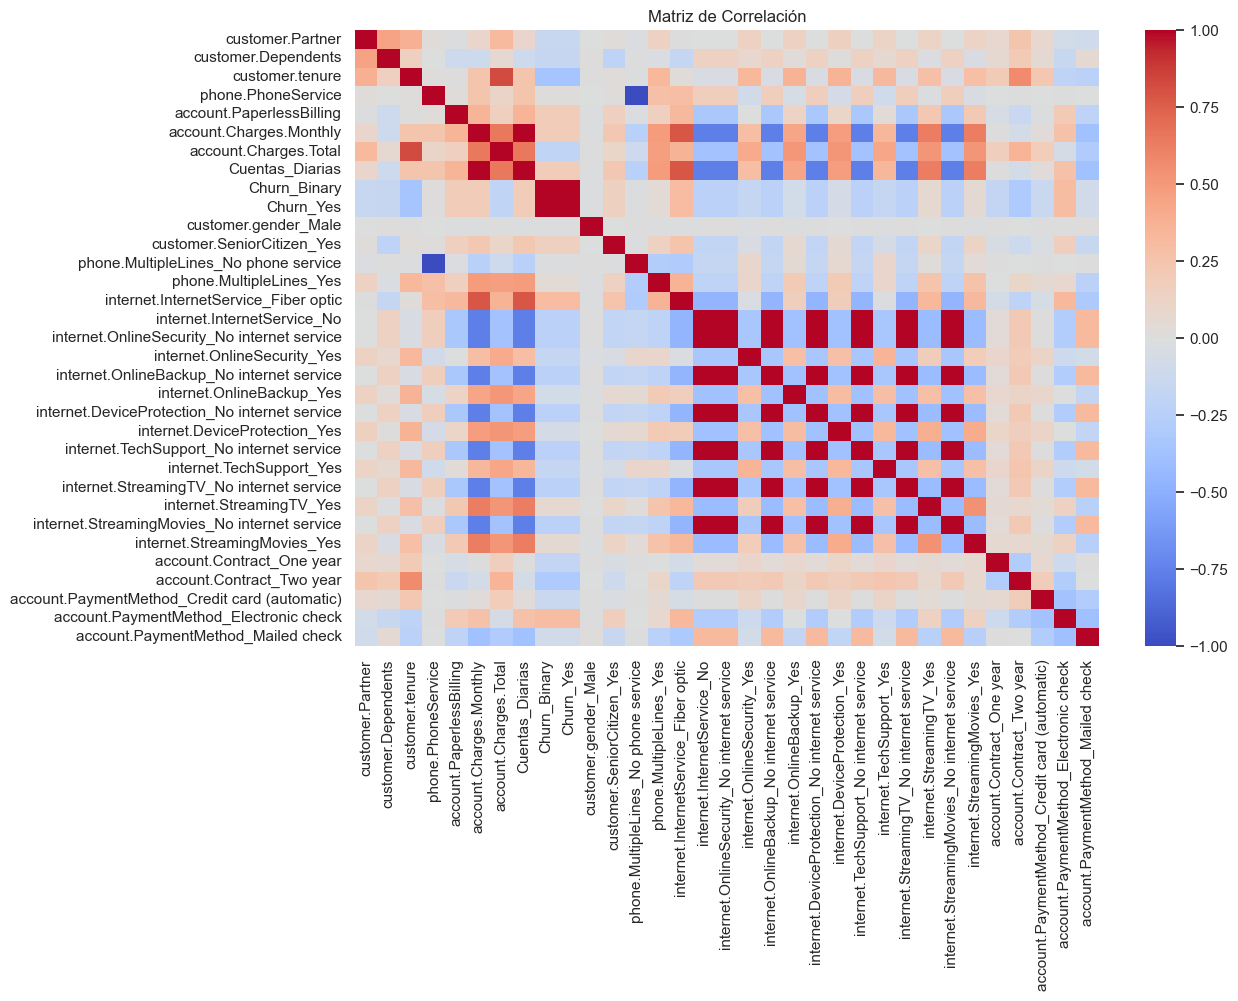

In [55]:
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlación")

plt.show()

CORRELACIÓN ESPECÍFICA CON CHURN

Churn_Binary                              1.000000
Churn_Yes                                 1.000000
internet.InternetService_Fiber optic      0.307463
account.PaymentMethod_Electronic check    0.301455
Cuentas_Diarias                           0.192858
account.Charges.Monthly                   0.192858
account.PaperlessBilling                  0.191454
customer.SeniorCitizen_Yes                0.150541
internet.StreamingTV_Yes                  0.063254
internet.StreamingMovies_Yes              0.060860
Name: Churn_Binary, dtype: float64


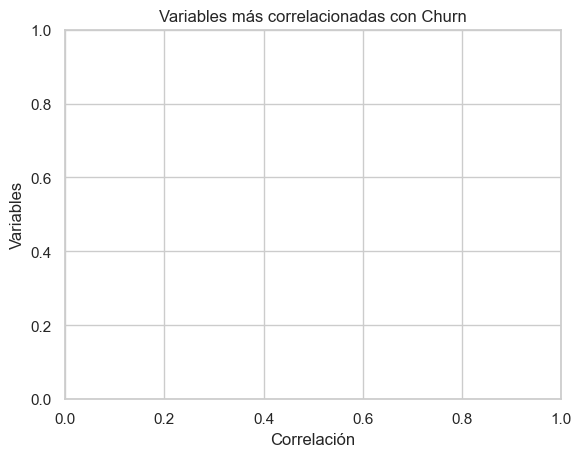

In [60]:
# matriz de correlación
correlation_matrix = df_encoded.corr()

# correlación con churn
churn_corr = correlation_matrix["Churn_Binary"].sort_values(ascending=False)

print(churn_corr.head(10))

plt.title("Variables más correlacionadas con Churn")
plt.xlabel("Correlación")
plt.ylabel("Variables")

plt.show()

VISUALIZACIÓN DE CORRELACIONES IMPORTANTES

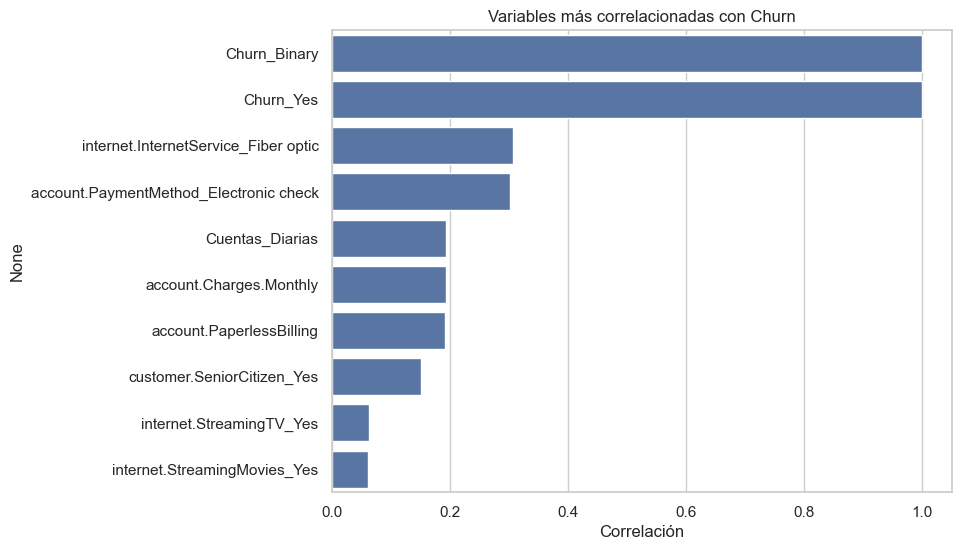

In [61]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=churn_corr.values[:10],
    y=churn_corr.index[:10]
)

plt.title("Variables más correlacionadas con Churn")

plt.xlabel("Correlación")

plt.show()

ANÁLISIS DIRIGIDO

### TENURE X CHURN

Se observa que los clientes que cancelan el servicio tienden a tener un menor tiempo de permanencia (tenure) en comparación con los clientes que permanecen activos.

Esto sugiere que los clientes nuevos tienen mayor probabilidad de cancelar el servicio, mientras que aquellos que permanecen más tiempo muestran mayor fidelidad hacia la empresa.

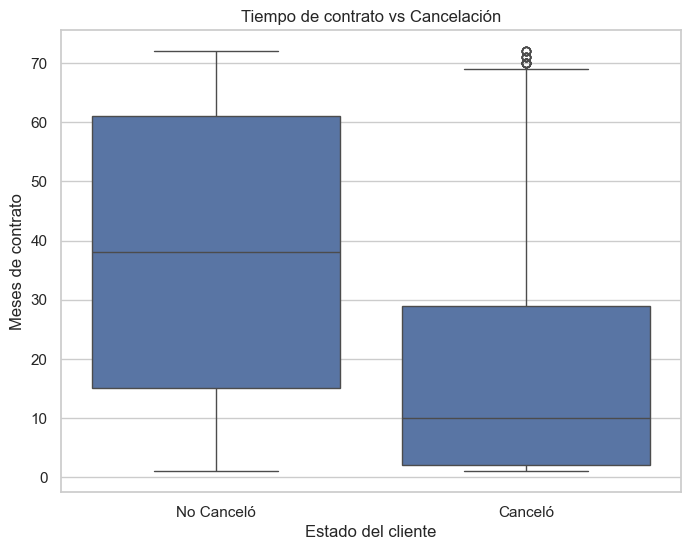

In [64]:
df_encoded["Churn_Label"] = df_encoded["Churn_Binary"].map({
    0: "No Canceló",
    1: "Canceló"
})

plt.figure(figsize=(8,6))

sns.boxplot(
    x=df_encoded["Churn_Label"],
    y=df_encoded["customer.tenure"]
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Estado del cliente")
plt.ylabel("Meses de contrato")

plt.show()

### TOTALCHARGES X CHURN

Los clientes que cancelan el servicio presentan, en promedio, un menor gasto total acumulado. Esto está relacionado con el tiempo de permanencia: clientes que han estado menos tiempo en la empresa naturalmente acumulan menores cargos totales.

Esto refuerza la idea de que los clientes más recientes son los más propensos a cancelar el servicio.

In [65]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["Churn"],
    y=df["TotalCharges"]
)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

KeyError: 'TotalCharges'

<Figure size 800x600 with 0 Axes>

### MONTHLYCHARGES X CHURN

El gráfico muestra que los clientes que cancelan el servicio tienden a tener cargos mensuales más altos. Esto podría indicar que los clientes con planes más costosos tienen mayor probabilidad de cancelar, posiblemente debido a la percepción de alto costo o falta de valor percibido.

Este factor podría ser relevante para estrategias de retención de clientes.

In [66]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x=df["Churn"],
    y=df["MonthlyCharges"]
)

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

KeyError: 'MonthlyCharges'

<Figure size 800x600 with 0 Axes>

### SCATTER PLOT

In [67]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["tenure"],
    y=df["TotalCharges"],
    hue=df["Churn"]
)

plt.title("Tenure vs Total Charges")

plt.show()

KeyError: 'tenure'

<Figure size 800x600 with 0 Axes>

### SEPARACIÓN DE DATOS TRAIN/TEST

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

VERIFICAR TAMAÑOS DE LOS CONJUNTOS

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)